In [1]:
import os
import cv2
import matplotlib.pyplot as plt

In [2]:
ruta_base = "dataset/Training_LR_escala4/s1"

archivos = sorted(os.listdir(ruta_base))
print(f"Archivos encontrados: {archivos}")

Archivos encontrados: ['1.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png']


 1.png → shape: (112, 92)
 2.png → shape: (112, 92)
 3.png → shape: (112, 92)
 4.png → shape: (112, 92)
 5.png → shape: (112, 92)


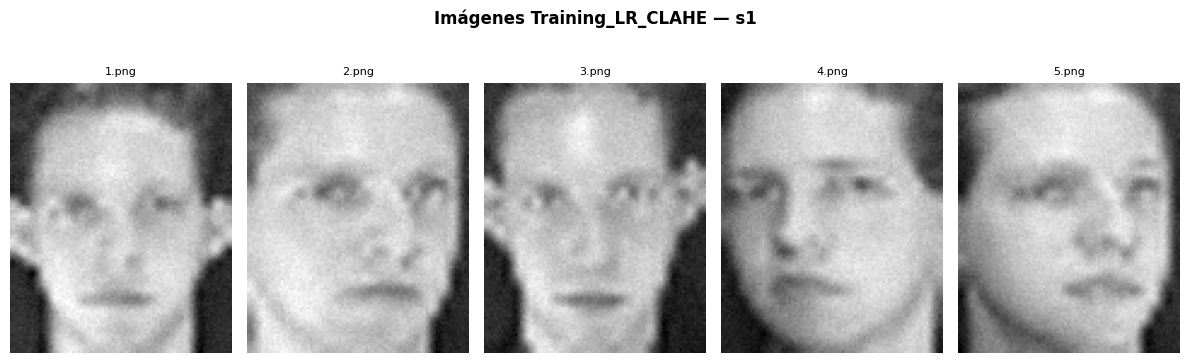

In [3]:
plt.figure(figsize=(12, 4))

for i, archivo in enumerate(archivos[:5]):
    ruta = os.path.join(ruta_base, archivo)
    img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f" No cargó: {archivo}")
        continue

    print(f" {archivo} → shape: {img.shape}")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(archivo, fontsize=8)
    plt.axis('off')

plt.suptitle("Imágenes Training_LR_CLAHE — s1", fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
def pipeline_correcto(imagen_lr, clip_limit=2.0, tile_grid_size=(8, 8)):
    # Paso 1: Eliminar ruido ANTES de CLAHE
    img_denoised = cv2.fastNlMeansDenoising(
        imagen_lr,
        h=10,              
        templateWindowSize=7,
        searchWindowSize=21
    )

    # Paso 2: CLAHE sobre imagen limpia
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    img_clahe = clahe.apply(img_denoised)

    return img_denoised, img_clahe

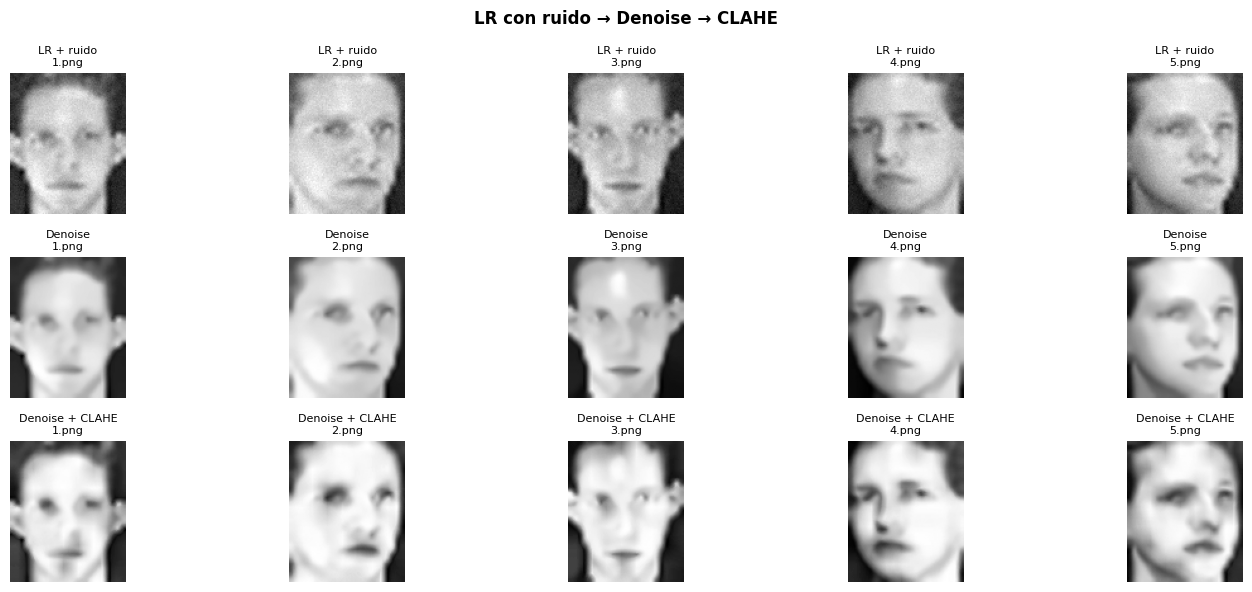

In [5]:
ruta_base = "dataset/Training_LR_escala4/s1"
archivos  = sorted(os.listdir(ruta_base))

plt.figure(figsize=(15, 6))

for i, archivo in enumerate(archivos[:5]):
    ruta = os.path.join(ruta_base, archivo)
    img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    denoised, clahe = pipeline_correcto(img)

    # Fila 1: LR con ruido (estado actual)
    plt.subplot(3, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"LR + ruido\n{archivo}", fontsize=8)
    plt.axis('off')

    # Fila 2: después de denoise
    plt.subplot(3, 5, i + 6)
    plt.imshow(denoised, cmap='gray')
    plt.title(f"Denoise\n{archivo}", fontsize=8)
    plt.axis('off')

    # Fila 3: después de CLAHE
    plt.subplot(3, 5, i + 11)
    plt.imshow(clahe, cmap='gray')
    plt.title(f"Denoise + CLAHE\n{archivo}", fontsize=8)
    plt.axis('off')

plt.suptitle("LR con ruido → Denoise → CLAHE", fontweight='bold')
plt.tight_layout()
plt.show()